# CHURN PREDICTION IN OVER-THE-TOP(OTT) FOR CUSTOMER RETENSION USING MACHINE LEARNING ALGORITHMS

In [ ]:
# IMPORTING LIBRARIES
import numpy as np # for numerical computing
import pandas as pd # for dataframes
import seaborn as sns # for easier visualization
from matplotlib import pyplot as plt # for visualization and to display plots
from matplotlib.colors import ListedColormap # import color maps

In [ ]:
# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

from math import sqrt

# to split train and test set
from sklearn.model_selection import train_test_split

#importing the required ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score

In [6]:
# Reading the dataset and storing it in  variable 'OTT_Churn'
OTT_Churn = pd.read_csv("ott_churn_model_dataset.csv")
# Printing the dataset
OTT_Churn

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2020,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2020,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2020,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2020,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2020,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2020,997132,385-7387,Female,54,75,no,yes,182.25,11.3,20.66,97,5,4.0,2,NaN
1996,2020,998086,383-9255,Male,45,127,no,no,273.45,9.3,30.99,116,3,3.0,1,0.0
1997,2020,998474,353-2080,NaN,53,94,no,no,128.85,15.6,14.60,110,16,5.0,0,0.0
1998,2020,998934,359-7788,Male,40,94,no,no,178.05,10.4,20.18,100,6,NaN,3,0.0


In [7]:
# Dropping the column 'customer_id' and 'year'
OTT_Churn.drop('customer_id', axis='columns', inplace=True)
OTT_Churn.drop('year', axis='columns', inplace=True)

In [8]:
# Seeing the data types of each and every attribute
OTT_Churn.dtypes

,0
phone_no,object
gender,object
age,int64
no_of_days_subscribed,int64
multi_screen,object
mail_subscribed,object
weekly_mins_watched,float64
minimum_daily_mins,float64
maximum_daily_mins,float64
weekly_max_night_mins,int64


In [9]:
# seeing the information of dataset
OTT_Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   phone_no                2000 non-null   object 
 1   gender                  1976 non-null   object 
 2   age                     2000 non-null   int64  
 3   no_of_days_subscribed   2000 non-null   int64  
 4   multi_screen            2000 non-null   object 
 5   mail_subscribed         2000 non-null   object 
 6   weekly_mins_watched     2000 non-null   float64
 7   minimum_daily_mins      2000 non-null   float64
 8   maximum_daily_mins      2000 non-null   float64
 9   weekly_max_night_mins   2000 non-null   int64  
 10  videos_watched          2000 non-null   int64  
 11  maximum_days_inactive   1972 non-null   float64
 12  customer_support_calls  2000 non-null   int64  
 13  churn                   1965 non-null   float64
dtypes: float64(5), int64(5), object(4)
memor

In [10]:
# Printing all the columns of dataset
OTT_Churn.columns

Index(['phone_no', 'gender', 'age', 'no_of_days_subscribed', 'multi_screen',
       'mail_subscribed', 'weekly_mins_watched', 'minimum_daily_mins',
       'maximum_daily_mins', 'weekly_max_night_mins', 'videos_watched',
       'maximum_days_inactive', 'customer_support_calls', 'churn'],
      dtype='object')

Types of features :

1)Categorical : gender, multi_screen, mail_subscribed, churn

2)Continuous : age, no_of_days_subscribed, weekly_mins_watched, minimum_daily_mins, maximum_daily_mins, weekly_max_night_mins, videos_watched, maximum_days_inactive, customer_support_calls

3)Alphanumeric: phone_no

Since the attribute 'phone_no' is alphanumeric we will drop that attribute too

In [11]:
OTT_Churn.drop('phone_no', axis='columns', inplace=True)

In [12]:
OTT_Churn.head()

,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0


# Handling Null Values

In [13]:
OTT_Churn.isnull().sum()

,0
gender,24
age,0
no_of_days_subscribed,0
multi_screen,0
mail_subscribed,0
weekly_mins_watched,0
minimum_daily_mins,0
maximum_daily_mins,0
weekly_max_night_mins,0
videos_watched,0


We found the null values in the attributes 'gender', 'maximum_days_inactive', 'churn'. We fill with mode in 'gender' and with median in 'maximum_days_inactive', 'churn'.


In [14]:
# Replacing missing values with mode in the 'gender' attribute
print("The Mode is :", (OTT_Churn.gender.mode()))

The Mode is : 0    Male
Name: gender, dtype: object


In [15]:
OTT_Churn.gender.fillna('Male',inplace=True)

In [16]:
# Replacing missing values with mode in the 'maximum_days_inactive.median' attribute
print("The Median is :", int(OTT_Churn.maximum_days_inactive.median()))

The Median is : 3


In [17]:
OTT_Churn.maximum_days_inactive.fillna(3, inplace=True)

In [18]:
# Replacing missing values with mode in the 'churn' attribute
print("The Median is :", int(OTT_Churn.churn.median()))

The Median is : 0


In [19]:
OTT_Churn.churn.fillna(0, inplace=True)

We will check whether null values are there

In [20]:
OTT_Churn.isnull().sum()

,0
gender,0
age,0
no_of_days_subscribed,0
multi_screen,0
mail_subscribed,0
weekly_mins_watched,0
minimum_daily_mins,0
maximum_daily_mins,0
weekly_max_night_mins,0
videos_watched,0


Therefore there are no missing values and we can proceed further

# Outlier Detection

Since every record is important and have impact on churn prediction we let the outliers also be part of the built machine learning models.

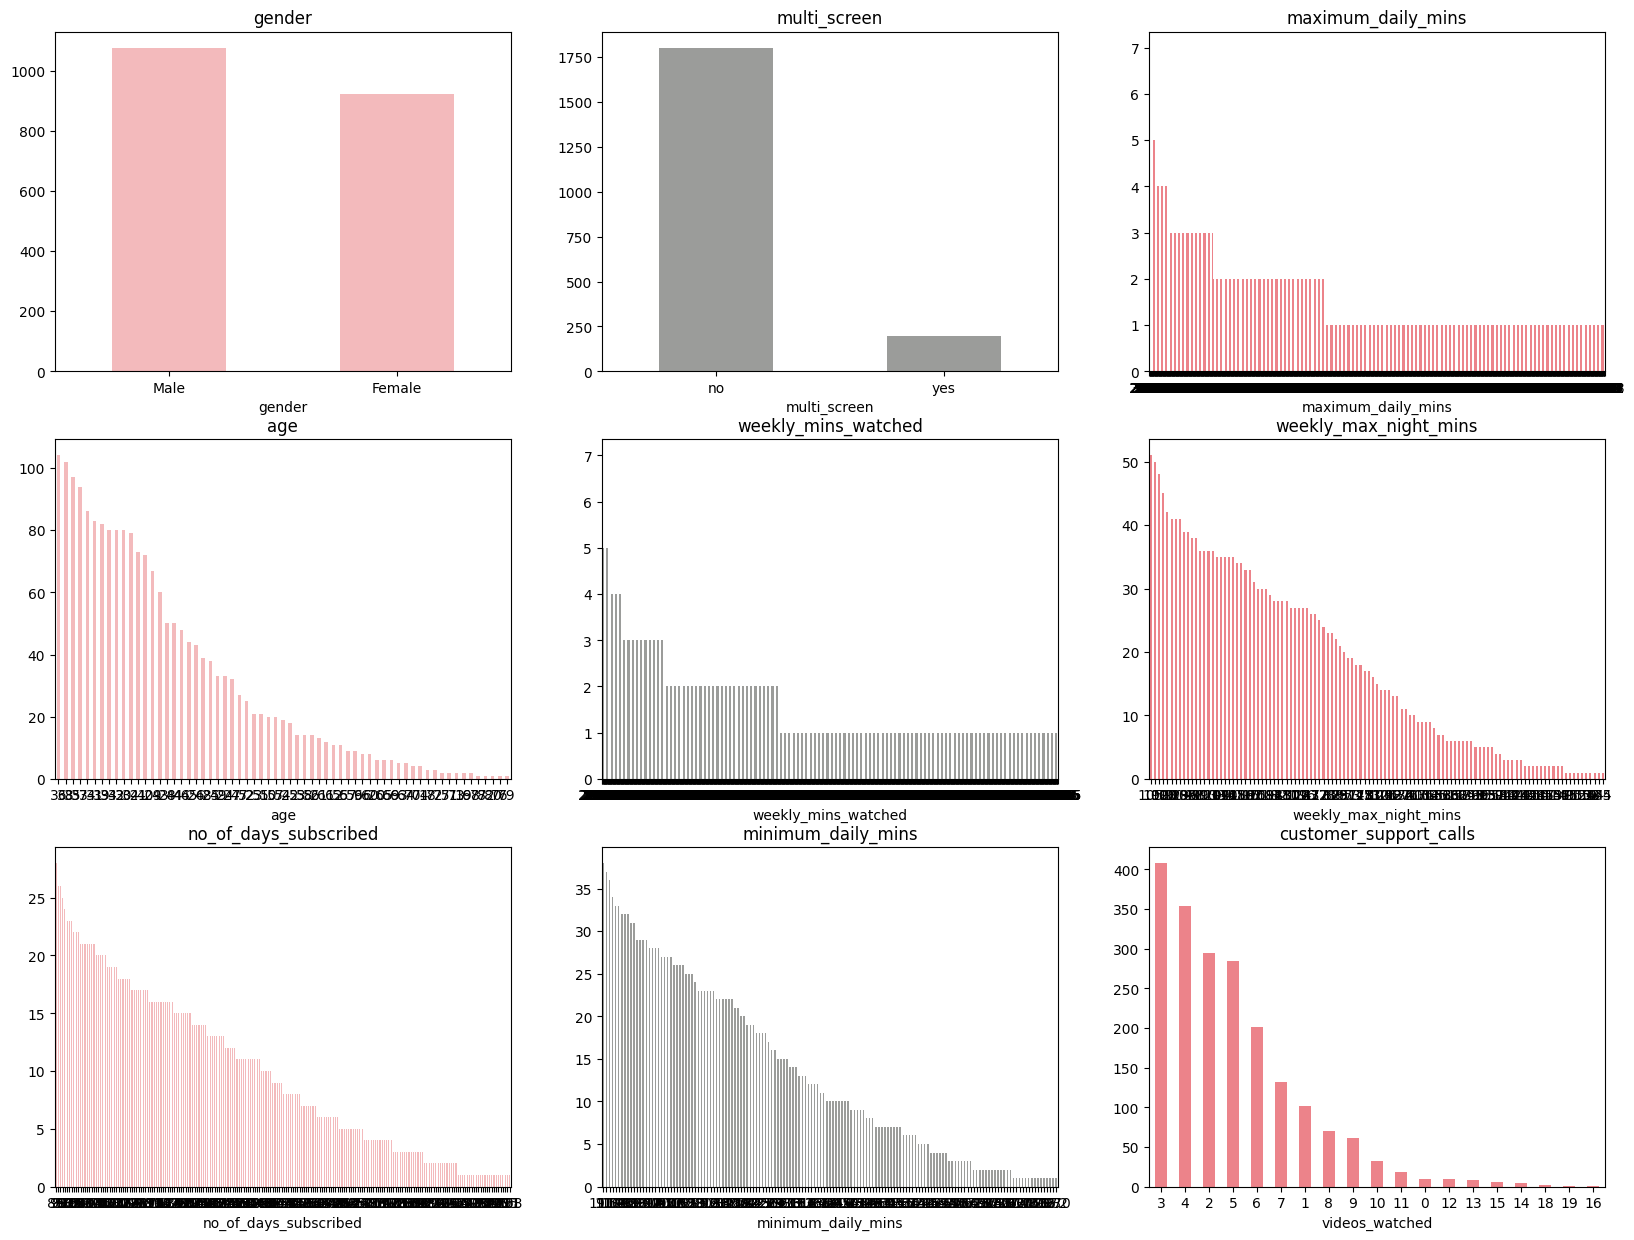

In [21]:
# Plotting Bar chart
BarPlot = OTT_Churn[['gender','age','no_of_days_subscribed','multi_screen','weekly_mins_watched',
                      'minimum_daily_mins','maximum_daily_mins','weekly_max_night_mins','videos_watched',
                     'maximum_days_inactive','customer_support_calls']]
fig, axes = plt.subplots(nrows = 3,ncols = 3,
figsize = (20,15))
for i, item in enumerate(BarPlot):
    if i < 3:
        ax = OTT_Churn[item].value_counts().plot(kind = 'bar',ax=axes[i,0],rot = 0, color ='#f3babc' )

    elif i >=3 and i < 6:
        ax = OTT_Churn[item].value_counts().plot(kind = 'bar',ax=axes[i-3,1], rot = 0,color ='#9b9c9a')

    elif i < 9:
        ax = OTT_Churn[item].value_counts().plot(kind = 'bar',ax=axes[i-6,2],rot = 0,color = '#ec838a')
    ax.set_title(item)

# Scatter Plot

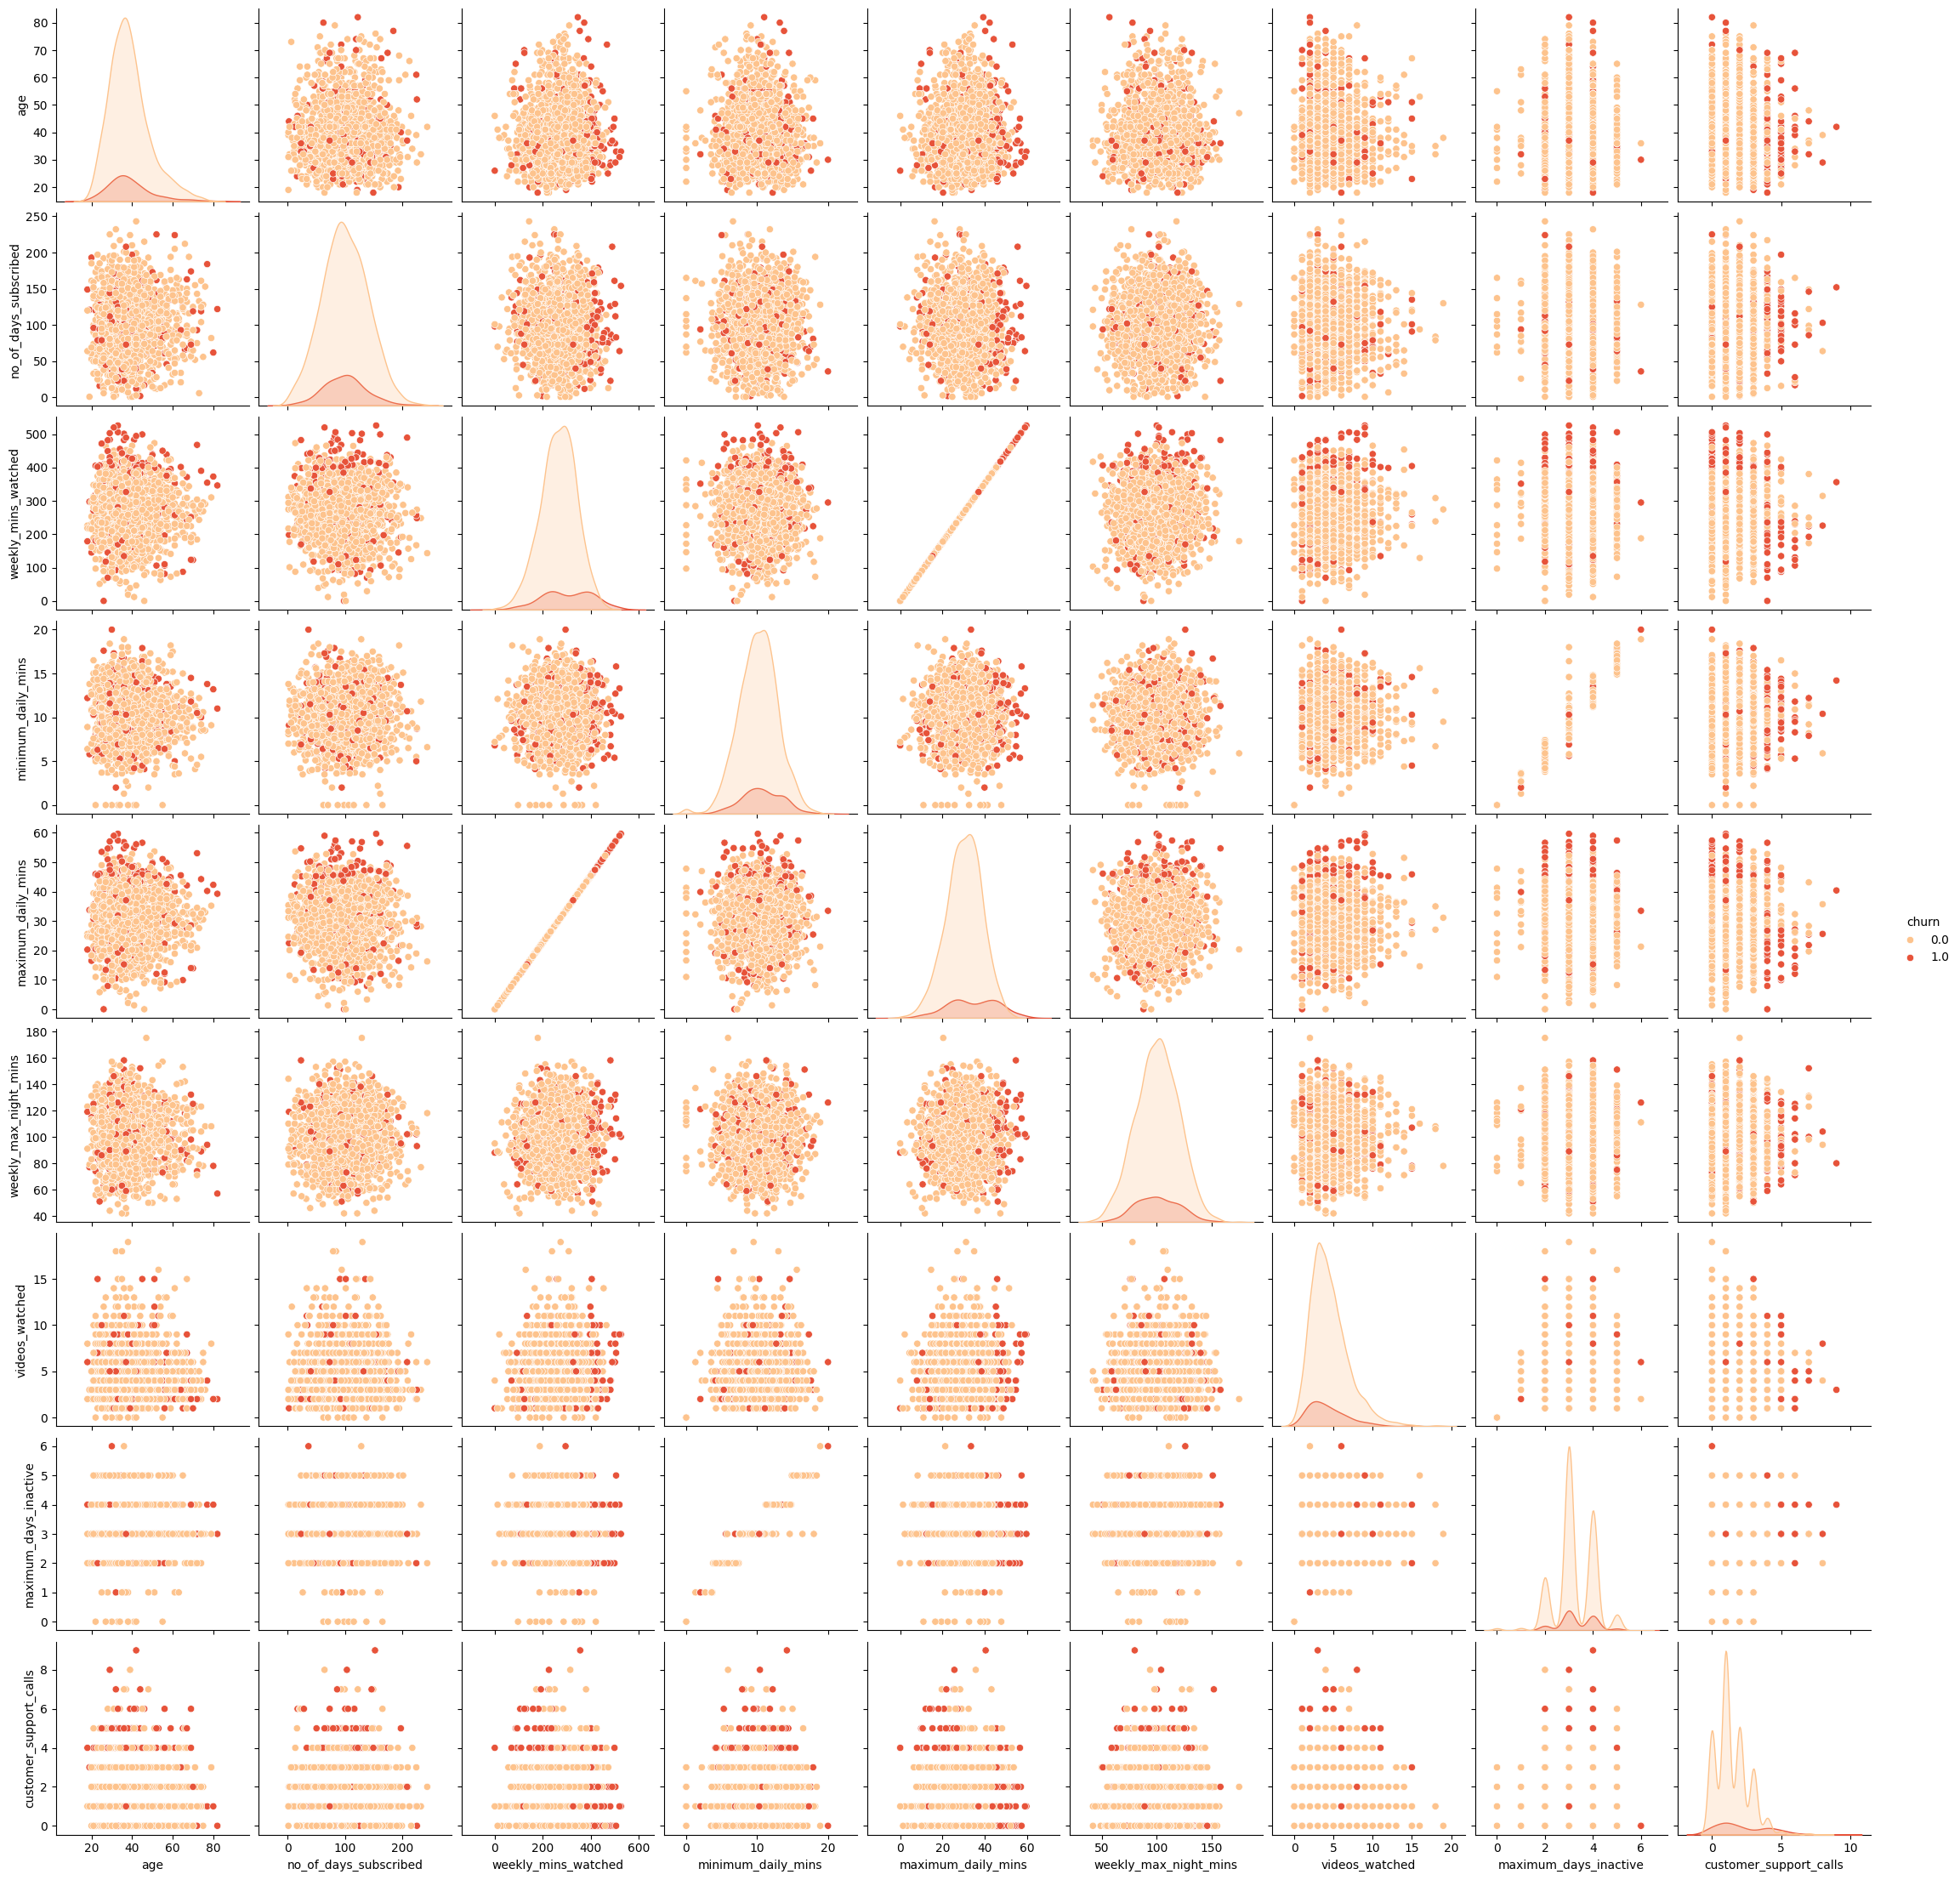

In [22]:
# Scatter plot
col = OTT_Churn.columns
plot = sns.pairplot(OTT_Churn[col],hue='churn',palette='OrRd')

# Correlation Matrix

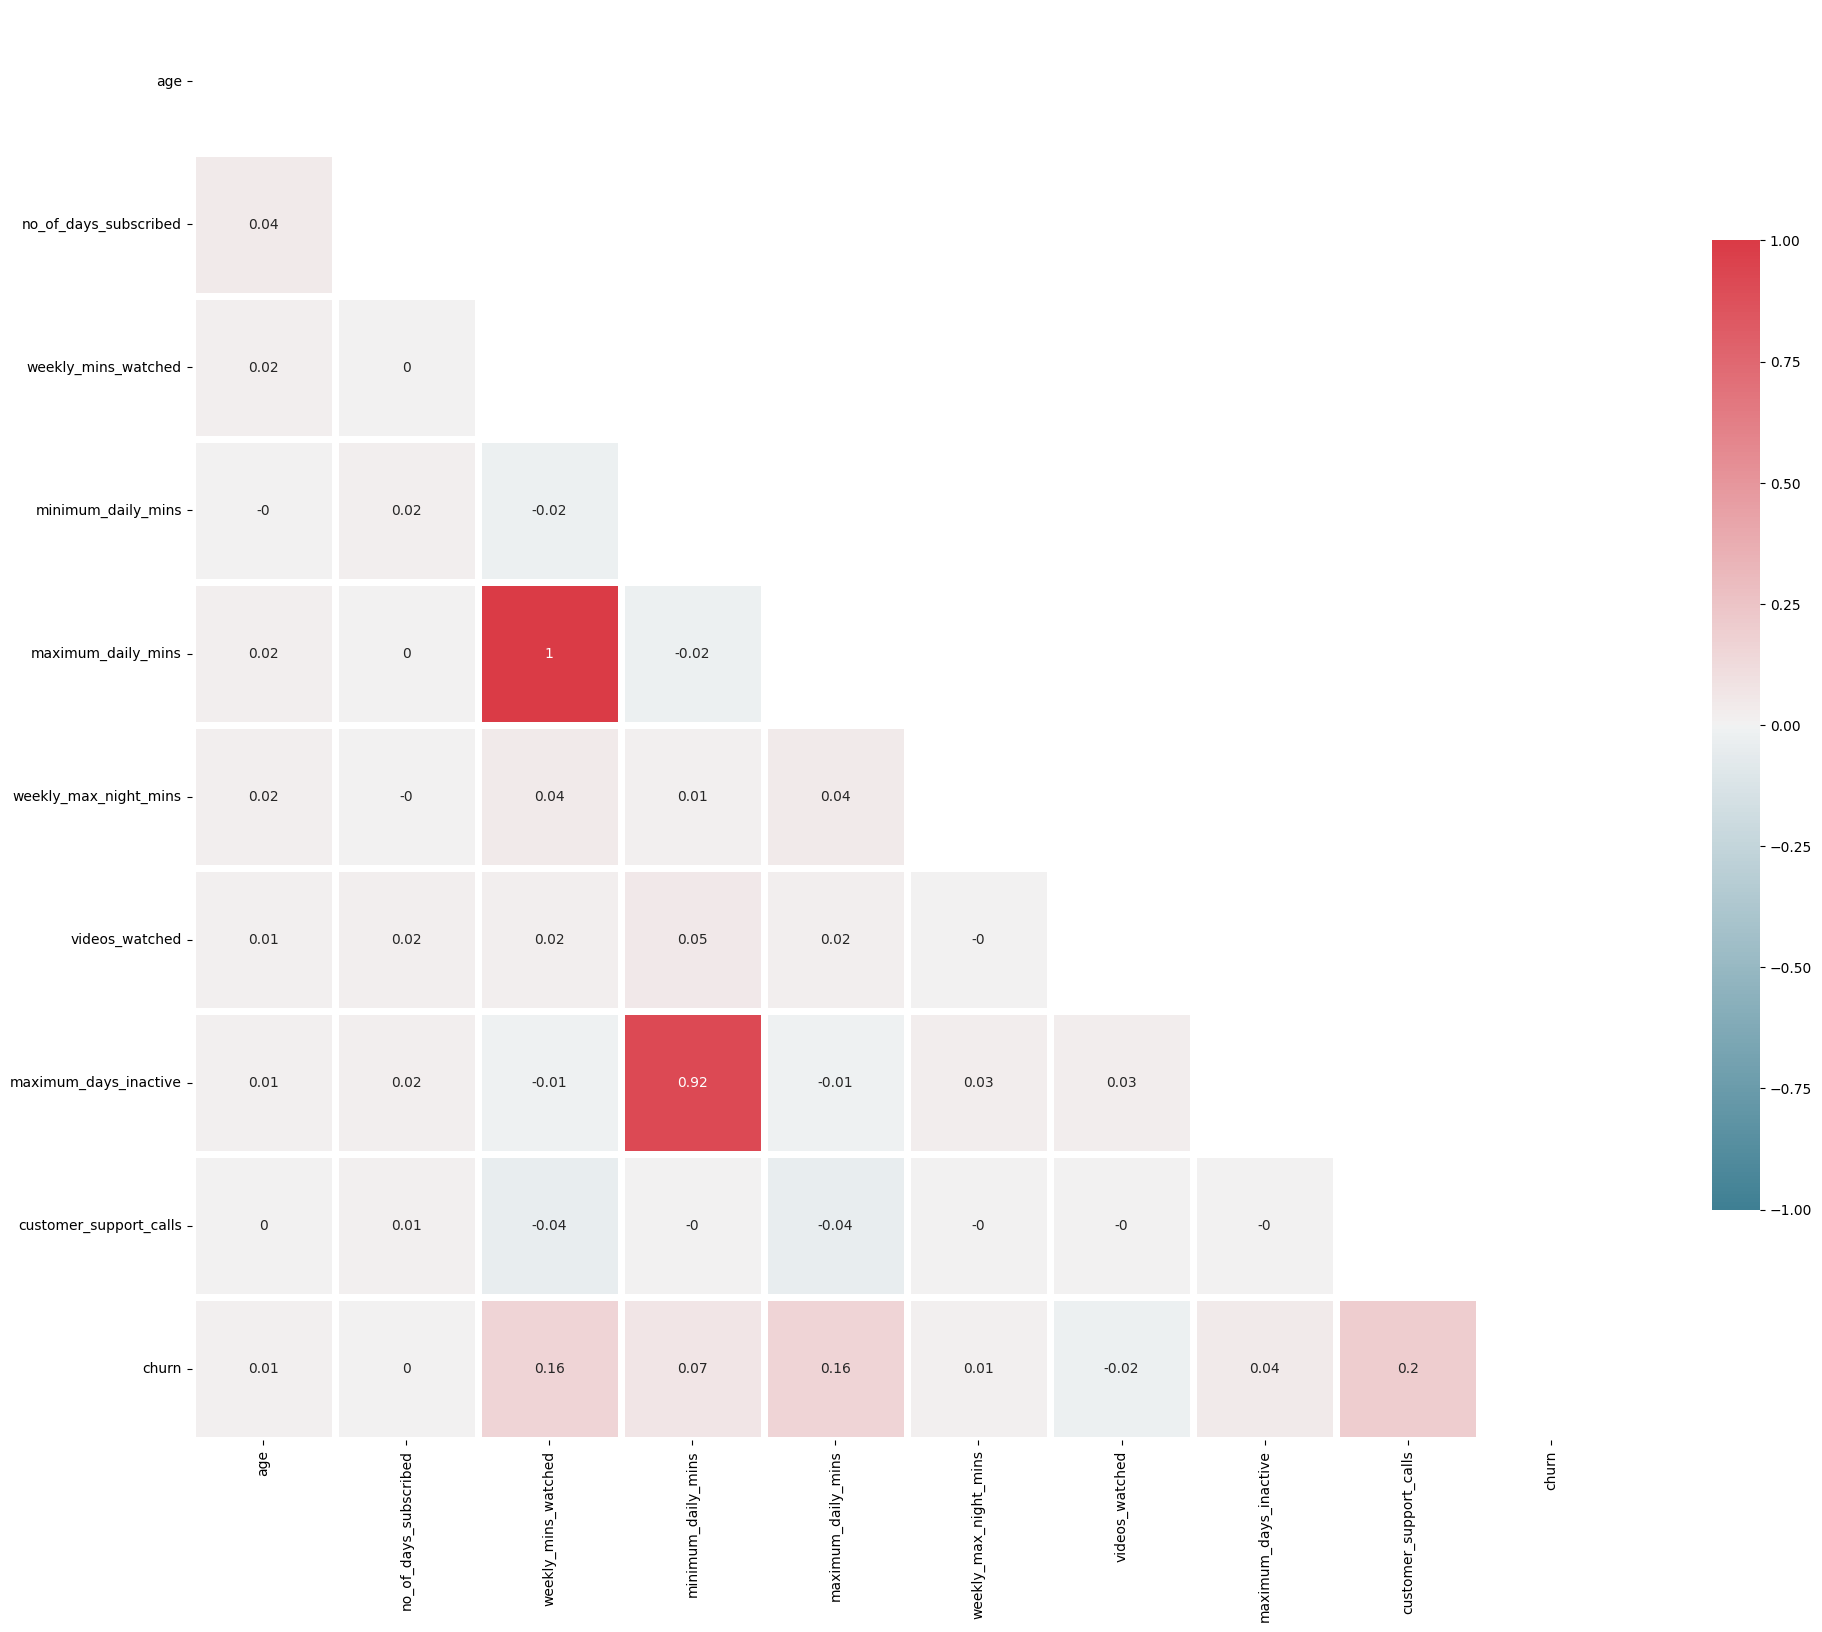

In [23]:
#plotting correlation matrix
corr = OTT_Churn.corr(numeric_only=True).round(2) # Add numeric_only=True

mask = np.zeros_like(corr, dtype = bool)
mask[np.triu_indices_from(mask)]  = True

f, ax = plt.subplots(figsize = (20,20))

cmap = sns.diverging_palette(220, 10, as_cmap = True)

sns.heatmap(corr, mask = mask, cmap = cmap, vmin = -1, vmax = 1, center = 0, square= True,
           linewidth = 5, cbar_kws = {"shrink": .5}, annot = True)

plt.tight_layout()

# Converting Categorical Data Into Numerical Data

In [24]:
# Converting through dummies function and storing it in variable 'Churn'
Churn = pd.get_dummies(OTT_Churn,columns=['gender','multi_screen','mail_subscribed'],drop_first=True)
Churn.head()

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,gender_Male,multi_screen_yes,mail_subscribed_yes
0,36,62,148.35,12.2,16.81,82,1,4.0,1,0.0,False,False,False
1,39,149,294.45,7.7,33.37,87,3,3.0,2,0.0,False,False,False
2,65,126,87.30,11.9,9.89,91,1,4.0,5,1.0,False,False,False
3,24,131,321.30,9.5,36.41,102,4,3.0,3,0.0,False,False,True
4,40,191,243.00,10.9,27.54,83,7,3.0,1,0.0,False,False,False


# Splitting out data into X: features and Y: target

In [25]:
#Splitting out training data into X: features and Y: target
X = Churn.drop("churn",axis=1)
Y = Churn["churn"]

# Standardization of Data

In [26]:
# Importing library
from sklearn.preprocessing import StandardScaler

In [27]:
sc=StandardScaler()
sc=sc.fit(X)
X=sc.transform(X)

# Splitting the data into Training Data and Test Data

In [28]:
# Splitting of training data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4,random_state=69)

# Decision Tree Classification

In [29]:
#Decision Tree Classifier
# Grid Search CV
decisiontree = DecisionTreeClassifier()
dep = np.arange(1,10)
param_grid = {'max_depth' : dep}

clf_cv = GridSearchCV(decisiontree, param_grid=param_grid, cv=5)

clf_cv.fit(X, Y)
clf_cv.best_params_,clf_cv.best_score_*100
print('Best value of max_depth:',clf_cv.best_params_)
print('Best score:',clf_cv.best_score_*100)

Best value of max_depth: {'max_depth': 5}
Best score: 91.35


In [30]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=5)

# Train Decision Tree Classifer
clf = clf.fit(X_train,Y_train)

#Predict the response for test dataset
Y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))

Accuracy: 0.91125


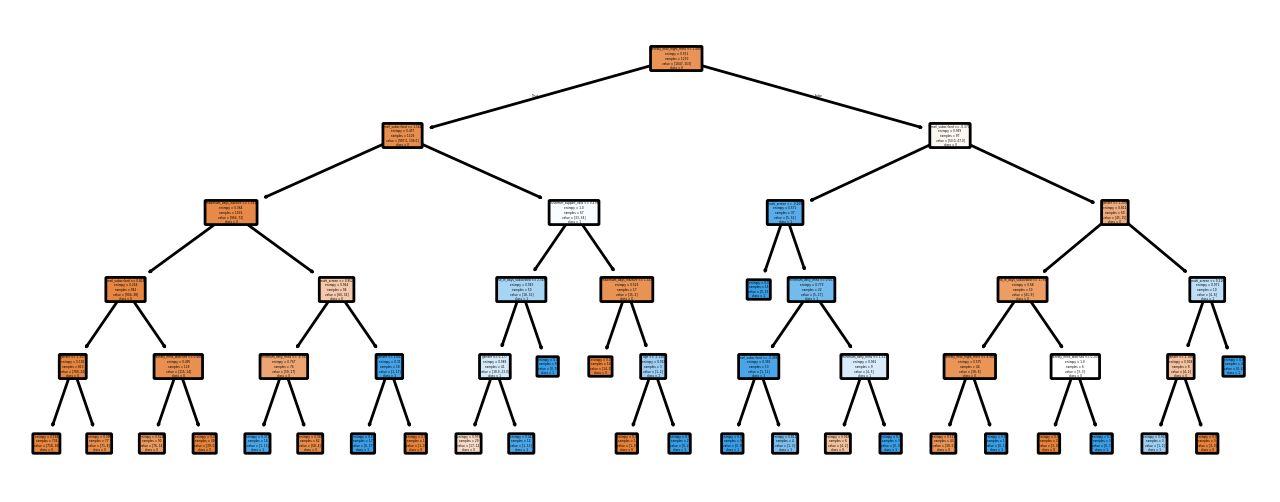

In [31]:
from sklearn import tree
plt.figure(figsize=(8, 3), dpi=200)
tree.plot_tree(clf,
               feature_names=OTT_Churn.columns,
               class_names=["0", "1"],
               filled=True,
               rounded=True);
plt.savefig('churn.png')

In [32]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  91.125 %


[[678  13]
 [ 58  51]]


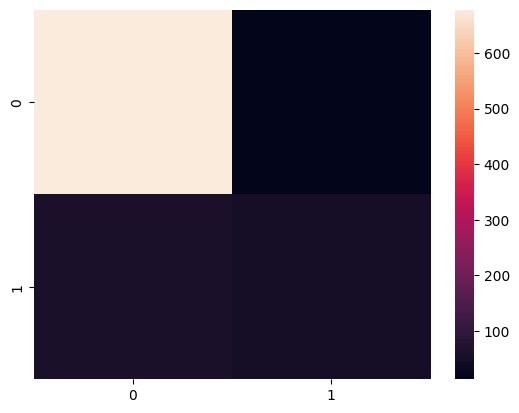

In [33]:
# Confusion matrix
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [34]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95       691
         1.0       0.80      0.47      0.59       109

    accuracy                           0.91       800
   macro avg       0.86      0.72      0.77       800
weighted avg       0.90      0.91      0.90       800



In [35]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_decisiontree_ID3=pd.DataFrame(data=Scores,index=['Decision_Tree_Classifier_ID3'])
model_decisiontree_ID3

,Accuracy,F1_score,Recall,Precision
Decision_Tree_Classifier_ID3,0.911,0.59,0.468,0.797


In [36]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="gini", max_depth=5)

# Train Decision Tree Classifer
clf = clf.fit(X_train,Y_train)

#Predict the response for test dataset
Y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))

Accuracy: 0.90625


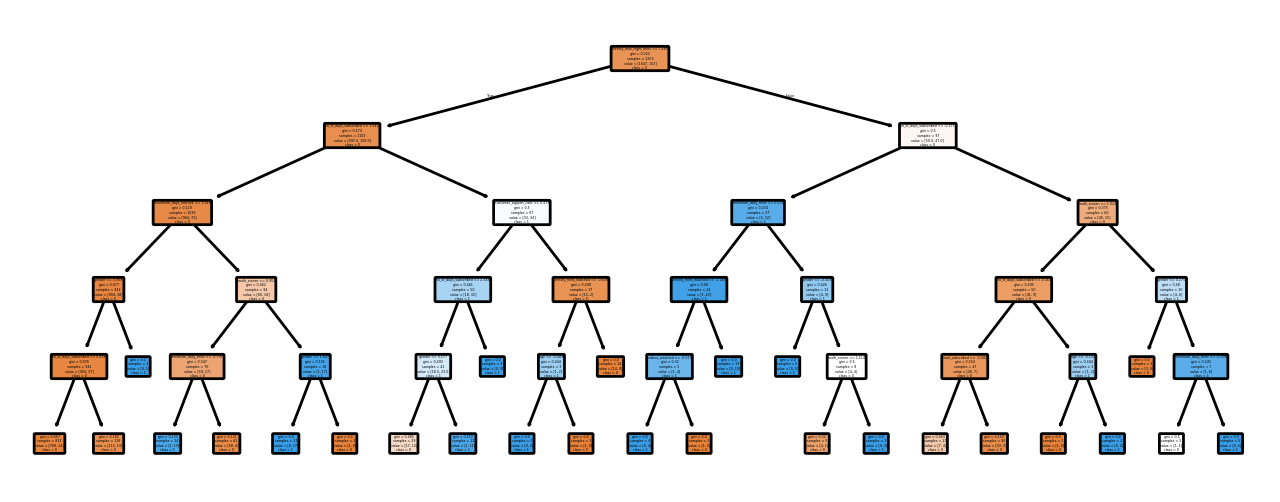

In [37]:
from sklearn import tree
plt.figure(figsize=(8, 3), dpi=200)
tree.plot_tree(clf,
               feature_names=OTT_Churn.columns,
               class_names=["0", "1"],
               filled=True,
               rounded=True);
plt.savefig('churn.png')

In [38]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  90.625 %


[[681  10]
 [ 65  44]]


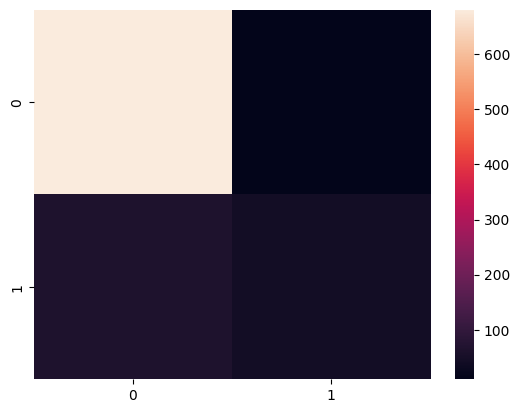

In [39]:
# Confusion matrix
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [40]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95       691
         1.0       0.81      0.40      0.54       109

    accuracy                           0.91       800
   macro avg       0.86      0.69      0.74       800
weighted avg       0.90      0.91      0.89       800



In [41]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_decisiontree_CART=pd.DataFrame(data=Scores,index=['Decision_Tree_Classifier_CART'])
model_decisiontree_CART

,Accuracy,F1_score,Recall,Precision
Decision_Tree_Classifier_CART,0.906,0.54,0.404,0.815


# Random Forest Classifier

In [42]:
#Random Forest Classifier

random_forest = RandomForestClassifier()
ne = np.arange(1,20)
param_grid = {'n_estimators' : ne}

rf_cv = GridSearchCV(random_forest, param_grid=param_grid, cv=5)

rf_cv.fit(X, Y)
print('Best value of n_estimators:',rf_cv.best_params_)
print('Best score:',rf_cv.best_score_*100)

Best value of n_estimators: {'n_estimators': 17}
Best score: 92.15


In [43]:
classifier = RandomForestClassifier(n_estimators = 11, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, Y_train)
Y_pred=classifier.predict(X_test)

In [44]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  91.25 %


[[677  14]
 [ 56  53]]


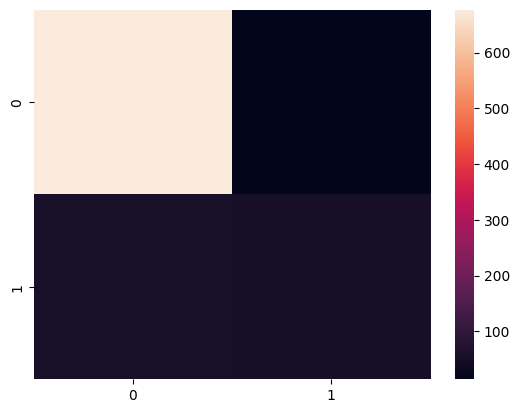

In [45]:
# Confusion matrix
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [46]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95       691
         1.0       0.79      0.49      0.60       109

    accuracy                           0.91       800
   macro avg       0.86      0.73      0.78       800
weighted avg       0.91      0.91      0.90       800



In [47]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_randomforest=pd.DataFrame(data=Scores,index=['Random_Forest'])
model_randomforest

,Accuracy,F1_score,Recall,Precision
Random_Forest,0.912,0.602,0.486,0.791


# Gradient Boosting Classifier

In [48]:
gbk = GradientBoostingClassifier()
ne = np.arange(1,20)
dep = np.arange(1,10)
param_grid = {'n_estimators' : ne,'max_depth' : dep}

gbk_cv = GridSearchCV(gbk, param_grid=param_grid, cv=5)

gbk_cv.fit(X, Y)
print('Best value of parameters:',gbk_cv.best_params_)
print('Best score:',gbk_cv.best_score_*100)

Best value of parameters: {'max_depth': 5, 'n_estimators': 19}
Best score: 92.4


In [49]:
classifier=GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0).fit(X_train, Y_train)
Y_pred=classifier.predict(X_test)

In [50]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  87.25 %


[[671  20]
 [ 82  27]]


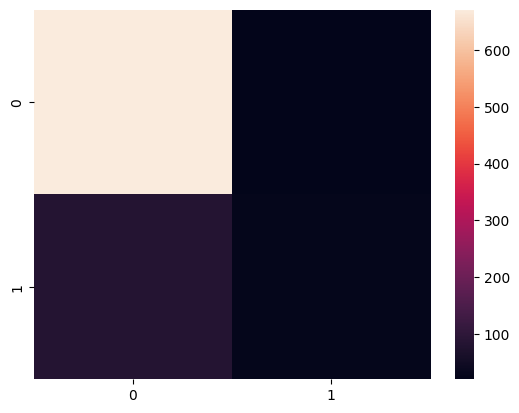

In [51]:
# Confusion Matrix
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [52]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.97      0.93       691
         1.0       0.57      0.25      0.35       109

    accuracy                           0.87       800
   macro avg       0.73      0.61      0.64       800
weighted avg       0.85      0.87      0.85       800



In [53]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_gradientboost=pd.DataFrame(data=Scores,index=['Gradient_Boosting'])
model_gradientboost

,Accuracy,F1_score,Recall,Precision
Gradient_Boosting,0.873,0.346,0.248,0.574


# XG Boosting

In [54]:
from xgboost import XGBClassifier
classifier = XGBClassifier()
classifier.fit(X_train, Y_train)
Y_pred = classifier.predict(X_test)

In [55]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  91.125 %


[[675  16]
 [ 55  54]]


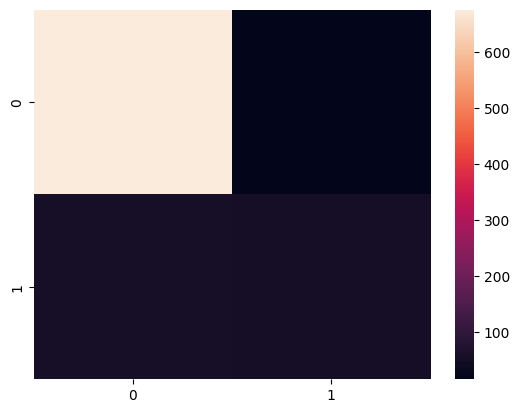

In [56]:
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [57]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95       691
         1.0       0.77      0.50      0.60       109

    accuracy                           0.91       800
   macro avg       0.85      0.74      0.78       800
weighted avg       0.90      0.91      0.90       800



In [58]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_XGboost=pd.DataFrame(data=Scores,index=['XG_Boosting'])
model_XGboost

,Accuracy,F1_score,Recall,Precision
XG_Boosting,0.911,0.603,0.495,0.771


In [59]:
All_Models = pd.concat([model_decisiontree_ID3,model_decisiontree_CART,model_randomforest,model_gradientboost,model_XGboost],axis = 0)
All_Models

,Accuracy,F1_score,Recall,Precision
Decision_Tree_Classifier_ID3,0.911,0.590,0.468,0.797
Decision_Tree_Classifier_CART,0.906,0.540,0.404,0.815
Random_Forest,0.912,0.602,0.486,0.791
Gradient_Boosting,0.873,0.346,0.248,0.574
XG_Boosting,0.911,0.603,0.495,0.771


In [60]:
Sort_Models = All_Models.sort_values(by=['Accuracy'],ascending = False)
Sort_Models

,Accuracy,F1_score,Recall,Precision
Random_Forest,0.912,0.602,0.486,0.791
Decision_Tree_Classifier_ID3,0.911,0.590,0.468,0.797
XG_Boosting,0.911,0.603,0.495,0.771
Decision_Tree_Classifier_CART,0.906,0.540,0.404,0.815
Gradient_Boosting,0.873,0.346,0.248,0.574


# Comparing Machine Learning Algorithms used by plotting Bar Chart

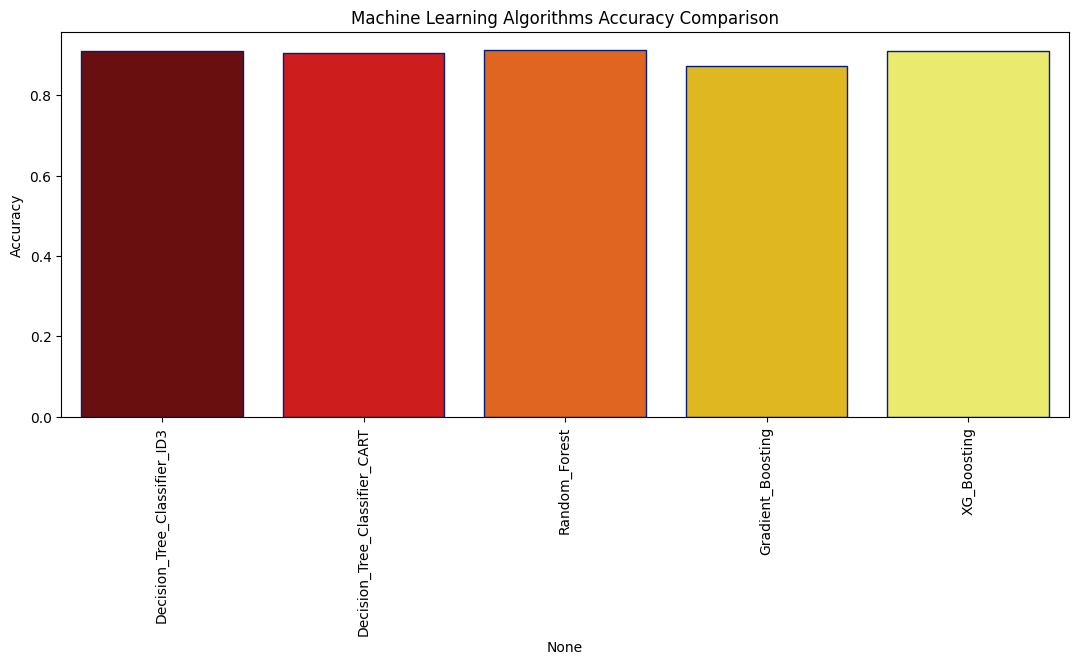

In [61]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_Models.index , y="Accuracy",data=All_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms Accuracy Comparison')
plt.show()

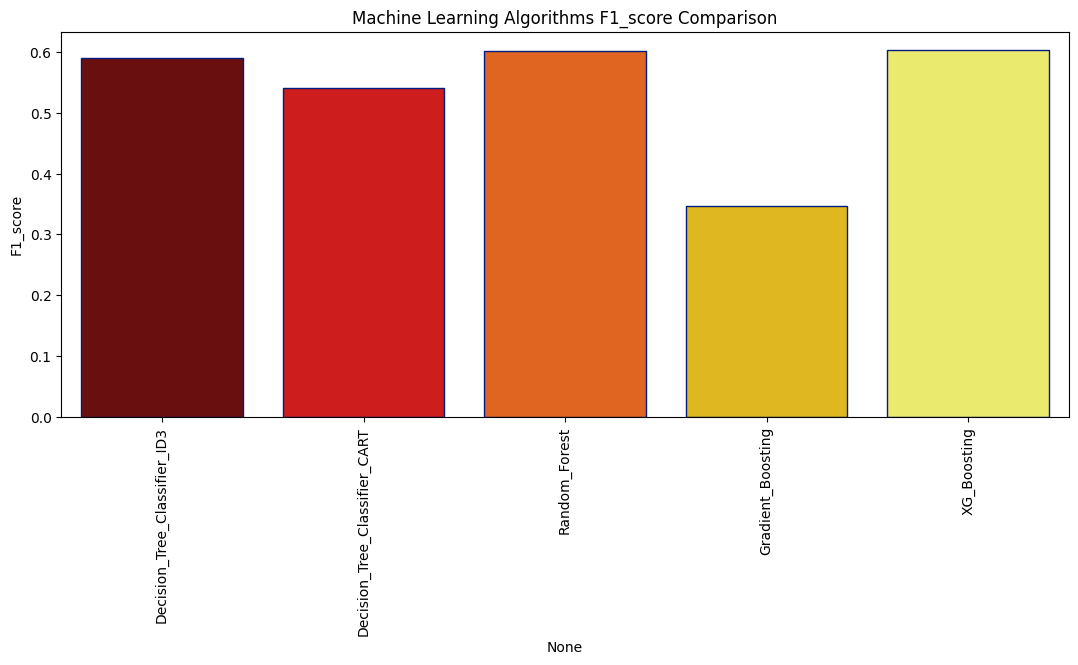

In [62]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_Models.index , y="F1_score",data=All_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms F1_score Comparison')
plt.show()

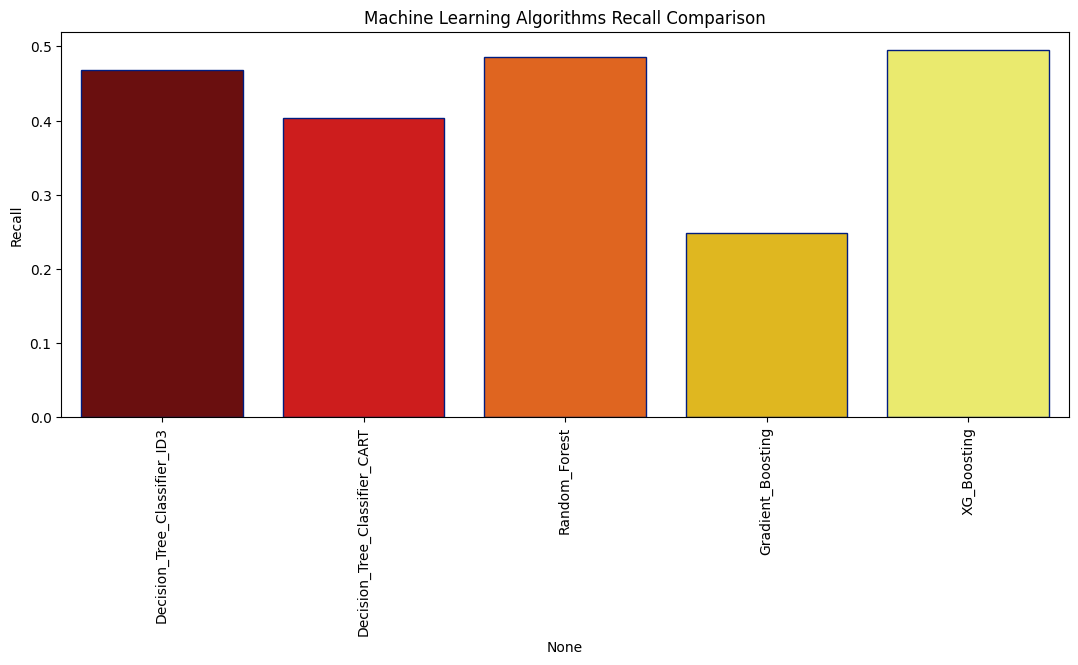

In [63]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_Models.index , y="Recall",data=All_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms Recall Comparison')
plt.show()

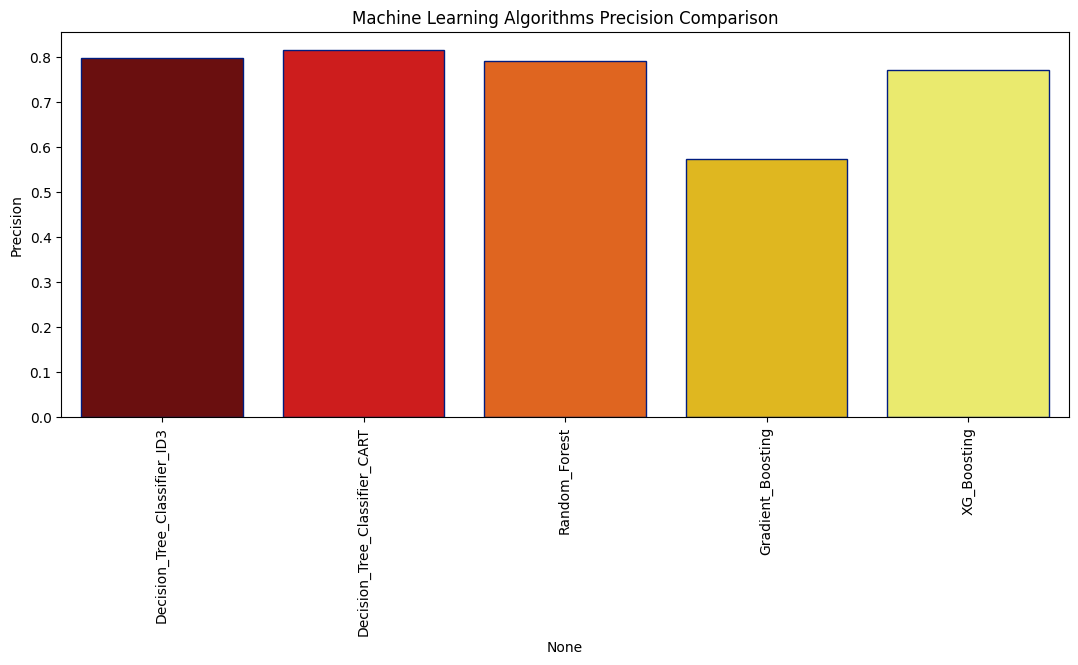

In [64]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_Models.index , y="Precision",data=All_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms Precision Comparison')
plt.show()

Here we observe that F1 score is less for all models, it is because the class is highly imbalnced and this class imbalance
is treated using SMOTE

In [65]:
print("Before OverSampling, counts of label '1': {}".format(sum(Y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(Y_train == 0)))

Before OverSampling, counts of label '1': 153
Before OverSampling, counts of label '0': 1047 



In [127]:
# import SMOTE module from imblearn library
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 2)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train.ravel())

In [128]:
print('After OverSampling, the shape of train_X: {}'.format(X_train_res.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(Y_train_res.shape))

print("After OverSampling, counts of label '1': {}".format(sum(Y_train_res == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(Y_train_res == 0)))

After OverSampling, the shape of train_X: (2094, 12)
After OverSampling, the shape of train_y: (2094,) 

After OverSampling, counts of label '1': 1047
After OverSampling, counts of label '0': 1047


# Checking model performance after over sampling

# Decision Tree Classification

In [129]:
#Decision Tree Classifier
# Grid Search CV
decisiontree = DecisionTreeClassifier()
dep = np.arange(1,10)
param_grid = {'max_depth' : dep}

clf_cv = GridSearchCV(decisiontree, param_grid=param_grid, cv=5)

clf_cv.fit(X, Y)
clf_cv.best_params_,clf_cv.best_score_*100
print('Best value of max_depth:',clf_cv.best_params_)
print('Best score:',clf_cv.best_score_*100)

Best value of max_depth: {'max_depth': 5}
Best score: 91.4


In [130]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=5)

# Train Decision Tree Classifer
clf = clf.fit(X_train_res, Y_train_res)

#Predict the response for test dataset
Y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))

Accuracy: 0.89


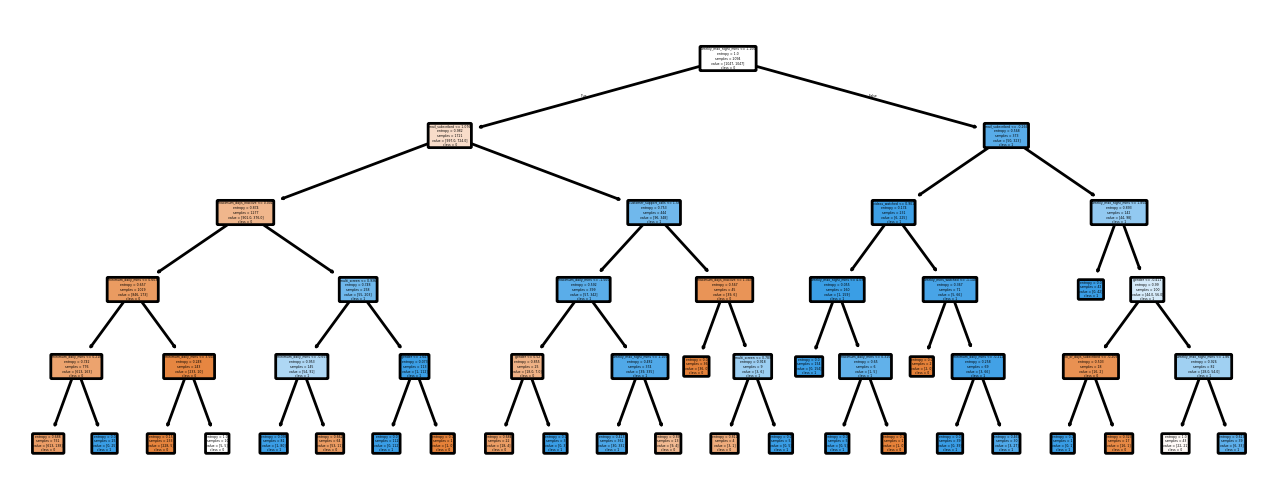

In [131]:
from sklearn import tree
plt.figure(figsize=(8, 3), dpi=200)
tree.plot_tree(clf,
               feature_names=OTT_Churn.columns,
               class_names=["0", "1"],
               filled=True,
               rounded=True);
plt.savefig('churn.png')

In [132]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  89.0 %


[[642  49]
 [ 39  70]]


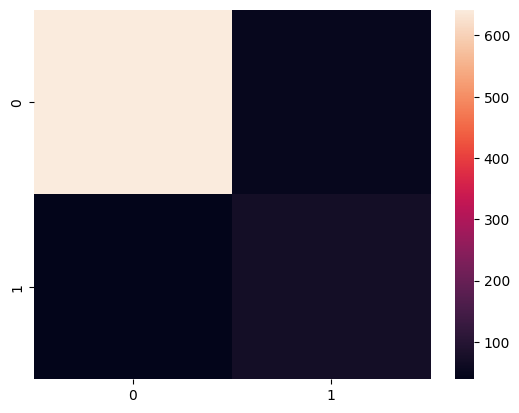

In [133]:
# Confusion matrix
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [134]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94       691
         1.0       0.59      0.64      0.61       109

    accuracy                           0.89       800
   macro avg       0.77      0.79      0.77       800
weighted avg       0.89      0.89      0.89       800



In [135]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_decisiontree_ID3_SMOTE=pd.DataFrame(data=Scores,index=['Decision_Tree_Classifier_ID3_SMOTE'])
model_decisiontree_ID3_SMOTE

,Accuracy,F1_score,Recall,Precision
Decision_Tree_Classifier_ID3_SMOTE,0.89,0.614,0.642,0.588


In [136]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="gini", max_depth=5)

# Train Decision Tree Classifer
clf = clf.fit(X_train_res, Y_train_res)

#Predict the response for test dataset
Y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))

Accuracy: 0.8975


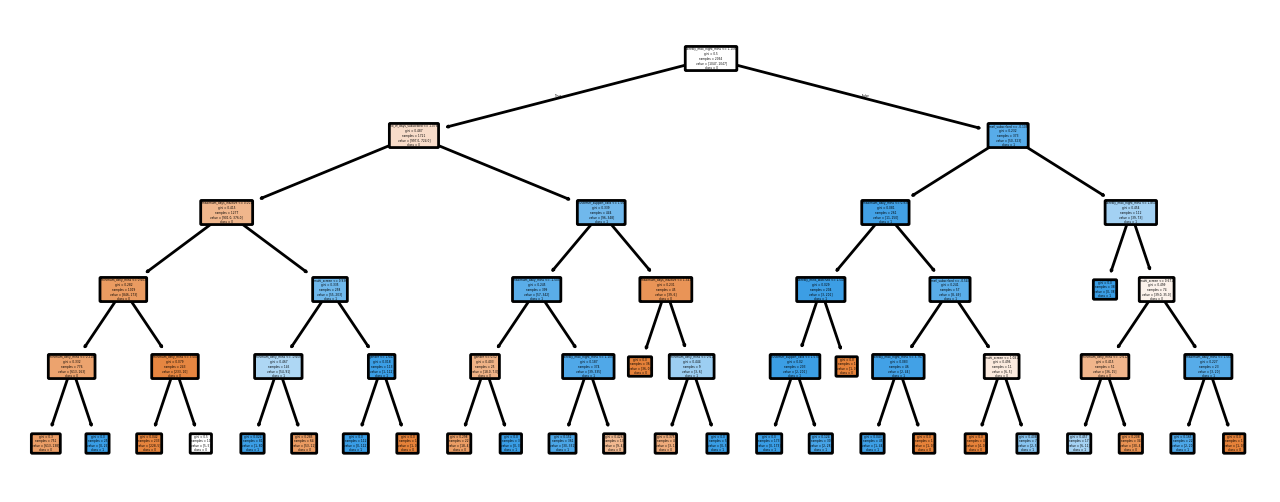

In [137]:
from sklearn import tree
plt.figure(figsize=(8, 3), dpi=200)
tree.plot_tree(clf,
               feature_names=OTT_Churn.columns,
               class_names=["0", "1"],
               filled=True,
               rounded=True);
plt.savefig('churn.png')

In [138]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  89.75 %


[[644  47]
 [ 35  74]]


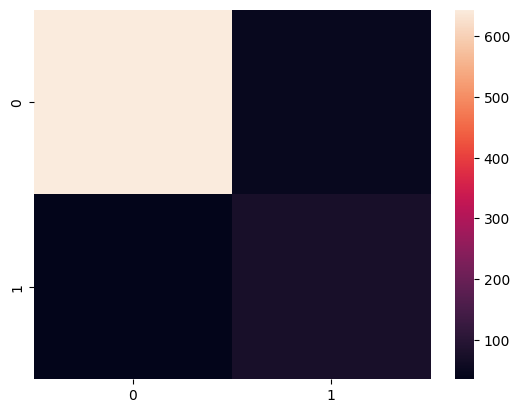

In [139]:
# Confusion matrix
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [140]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94       691
         1.0       0.61      0.68      0.64       109

    accuracy                           0.90       800
   macro avg       0.78      0.81      0.79       800
weighted avg       0.90      0.90      0.90       800



In [141]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_decisiontree_CART_SMOTE=pd.DataFrame(data=Scores,index=['Decision_Tree_Classifier_CART_SMOTE'])
model_decisiontree_CART_SMOTE

,Accuracy,F1_score,Recall,Precision
Decision_Tree_Classifier_CART_SMOTE,0.897,0.643,0.679,0.612


# Random Forest Classifier

In [142]:
#Random Forest Classifier

random_forest = RandomForestClassifier()
ne = np.arange(1,20)
param_grid = {'n_estimators' : ne}

rf_cv = GridSearchCV(random_forest, param_grid=param_grid, cv=5)

rf_cv.fit(X, Y)
print('Best value of n_estimators:',rf_cv.best_params_)
print('Best score:',rf_cv.best_score_*100)

Best value of n_estimators: {'n_estimators': 17}
Best score: 92.15000000000002


In [143]:
classifier = RandomForestClassifier(n_estimators = 11, criterion = 'entropy', random_state = 0)
classifier.fit(X_train_res, Y_train_res)
Y_pred=classifier.predict(X_test)

In [144]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  89.75 %


[[649  42]
 [ 40  69]]


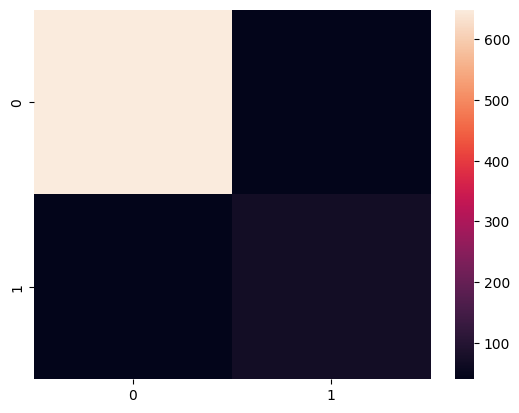

In [145]:
# Confusion matrix
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [146]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94       691
         1.0       0.62      0.63      0.63       109

    accuracy                           0.90       800
   macro avg       0.78      0.79      0.78       800
weighted avg       0.90      0.90      0.90       800



In [147]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_randomforest_SMOTE=pd.DataFrame(data=Scores,index=['Random_Forest_SMOTE'])
model_randomforest_SMOTE

,Accuracy,F1_score,Recall,Precision
Random_Forest_SMOTE,0.897,0.627,0.633,0.622


# Gradient Boosting Classifier

In [148]:
gbk = GradientBoostingClassifier()
ne = np.arange(1,20)
dep = np.arange(1,10)
param_grid = {'n_estimators' : ne,'max_depth' : dep}

gbk_cv = GridSearchCV(gbk, param_grid=param_grid, cv=5)

gbk_cv.fit(X, Y)
print('Best value of parameters:',gbk_cv.best_params_)
print('Best score:',gbk_cv.best_score_*100)

Best value of parameters: {'max_depth': 4, 'n_estimators': 17}
Best score: 92.2


In [149]:
classifier=GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0).fit(X_train_res, Y_train_res)
Y_pred=classifier.predict(X_test)

In [150]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93       691
         1.0       0.53      0.48      0.50       109

    accuracy                           0.87       800
   macro avg       0.72      0.71      0.71       800
weighted avg       0.87      0.87      0.87       800



In [151]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_gradientboost_SMOTE=pd.DataFrame(data=Scores,index=['Gradient_Boosting_SMOTE'])
model_gradientboost_SMOTE

,Accuracy,F1_score,Recall,Precision
Gradient_Boosting_SMOTE,0.871,0.502,0.477,0.531


# XG Boosting

In [159]:
from xgboost import XGBClassifier
classifier = XGBClassifier()
classifier.fit(X_train_res, Y_train_res)
Y_pred = classifier.predict(X_test)

In [160]:
accuracy = metrics.accuracy_score(Y_test,Y_pred)
confusion_matrix = metrics.confusion_matrix(Y_test,Y_pred)

print('The accuracy score is ',accuracy*100,'%')

The accuracy score is  90.875 %


[[661  30]
 [ 43  66]]


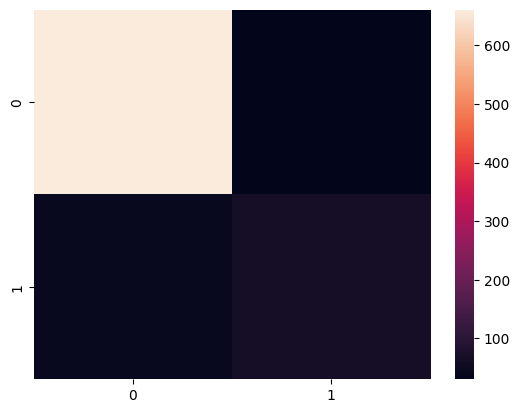

In [161]:
sns.heatmap(confusion_matrix)
print(confusion_matrix)

In [162]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95       691
         1.0       0.69      0.61      0.64       109

    accuracy                           0.91       800
   macro avg       0.81      0.78      0.80       800
weighted avg       0.90      0.91      0.91       800



In [163]:
Scores = {'Accuracy':round(accuracy_score(Y_test,Y_pred),3),'F1_score':round(f1_score(Y_test,Y_pred),3),'Recall':round(recall_score(Y_test,Y_pred),3),'Precision':round(precision_score(Y_test,Y_pred),3)}
Scores
model_XGboost_SMOTE=pd.DataFrame(data=Scores,index=['XG_Boosting_SMOTE'])
model_XGboost_SMOTE

,Accuracy,F1_score,Recall,Precision
XG_Boosting_SMOTE,0.909,0.644,0.606,0.688


In [164]:
All_ML_Models = pd.concat([model_decisiontree_ID3,model_decisiontree_CART,model_randomforest,
                           model_gradientboost,model_XGboost,
                           model_decisiontree_ID3_SMOTE,model_decisiontree_CART_SMOTE,model_randomforest_SMOTE,model_gradientboost_SMOTE,
                           model_XGboost_SMOTE],axis = 0)
All_ML_Models

,Accuracy,F1_score,Recall,Precision
Decision_Tree_Classifier_ID3,0.911,0.590,0.468,0.797
Decision_Tree_Classifier_CART,0.906,0.540,0.404,0.815
Random_Forest,0.912,0.602,0.486,0.791
Gradient_Boosting,0.873,0.346,0.248,0.574
XG_Boosting,0.911,0.603,0.495,0.771
Decision_Tree_Classifier_ID3_SMOTE,0.890,0.614,0.642,0.588
Decision_Tree_Classifier_CART_SMOTE,0.897,0.643,0.679,0.612
Random_Forest_SMOTE,0.897,0.627,0.633,0.622
Gradient_Boosting_SMOTE,0.871,0.502,0.477,0.531
XG_Boosting_SMOTE,0.909,0.644,0.606,0.688


In [165]:
All_ML_Models = pd.concat([model_decisiontree_ID3_SMOTE,model_decisiontree_CART_SMOTE,model_randomforest_SMOTE,
                           model_gradientboost_SMOTE,model_XGboost_SMOTE],axis = 0)
All_ML_Models

,Accuracy,F1_score,Recall,Precision
Decision_Tree_Classifier_ID3_SMOTE,0.890,0.614,0.642,0.588
Decision_Tree_Classifier_CART_SMOTE,0.897,0.643,0.679,0.612
Random_Forest_SMOTE,0.897,0.627,0.633,0.622
Gradient_Boosting_SMOTE,0.871,0.502,0.477,0.531
XG_Boosting_SMOTE,0.909,0.644,0.606,0.688


In [166]:
Sort_Models = All_ML_Models.sort_values(by=['Accuracy'],ascending = False)
Sort_Models

,Accuracy,F1_score,Recall,Precision
XG_Boosting_SMOTE,0.909,0.644,0.606,0.688
Decision_Tree_Classifier_CART_SMOTE,0.897,0.643,0.679,0.612
Random_Forest_SMOTE,0.897,0.627,0.633,0.622
Decision_Tree_Classifier_ID3_SMOTE,0.890,0.614,0.642,0.588
Gradient_Boosting_SMOTE,0.871,0.502,0.477,0.531


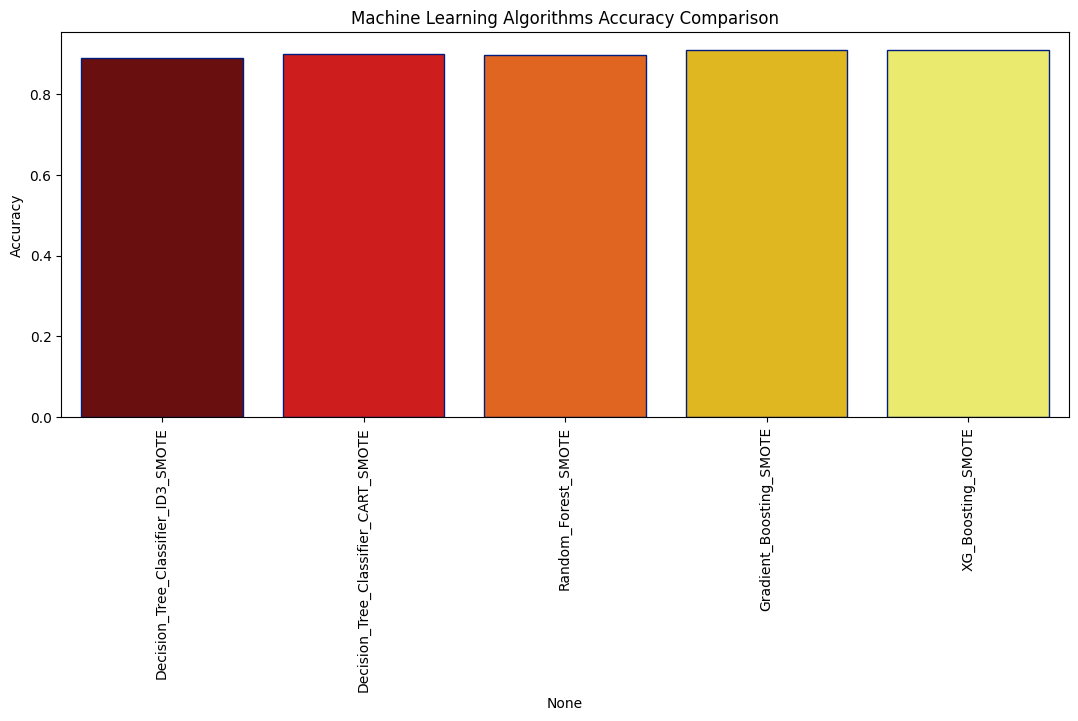

In [110]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_ML_Models.index , y="Accuracy",data=All_ML_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms Accuracy Comparison')
plt.show()

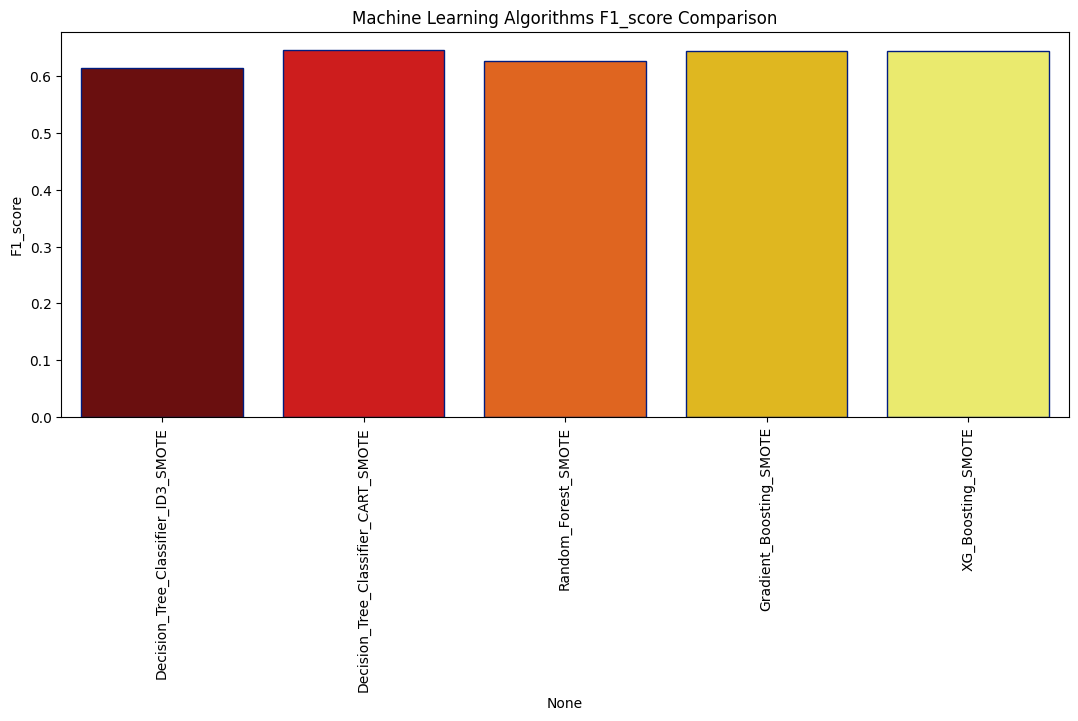

In [111]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_ML_Models.index , y="F1_score",data=All_ML_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms F1_score Comparison')
plt.show()

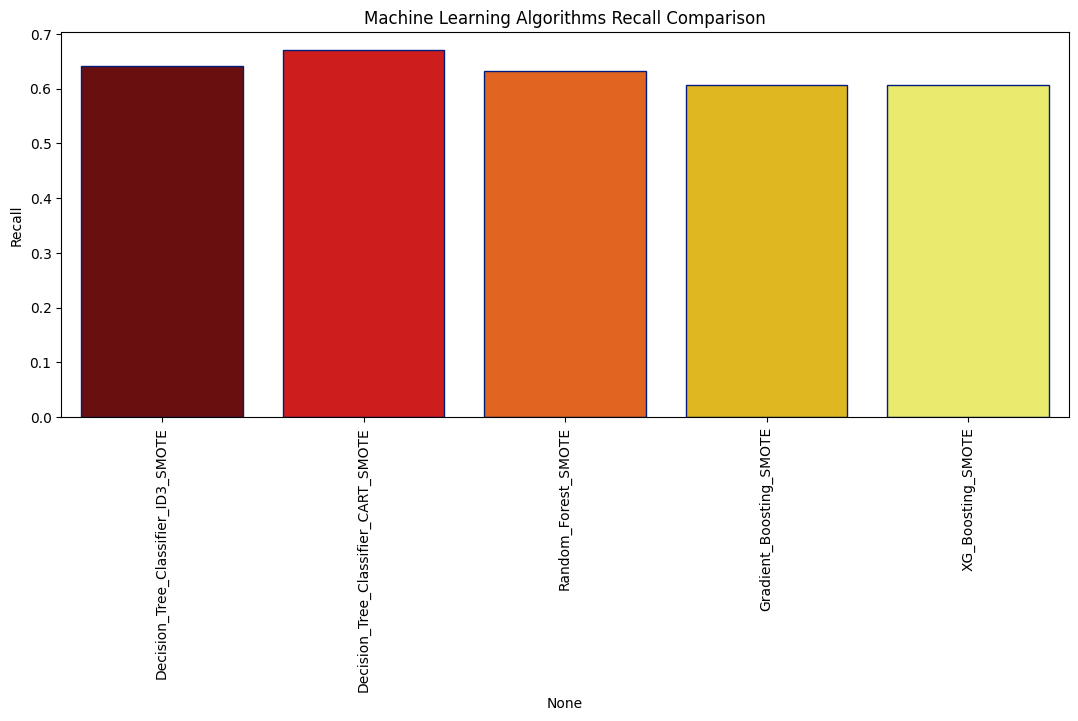

In [112]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_ML_Models.index , y="Recall",data=All_ML_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms Recall Comparison')
plt.show()

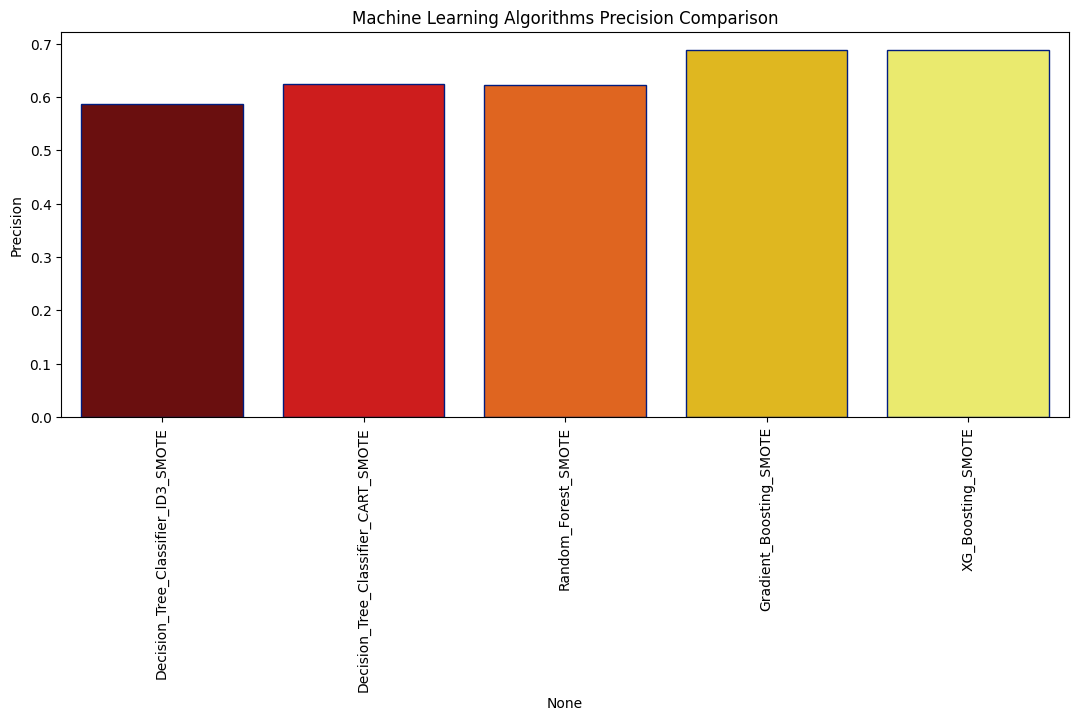

In [113]:
plt.subplots(figsize=(13,5))
sns.barplot(x=All_ML_Models.index , y="Precision",data=All_ML_Models,palette='hot',edgecolor=sns.color_palette('dark',7))
plt.xticks(rotation=90)
plt.title('Machine Learning Algorithms Precision Comparison')
plt.show()